# Embedding Collapse Study — Analysis

Exploratory analysis of geometry metrics across experiment runs.

In [2]:
import sys
sys.path.insert(0, '../src/embedding_collapse_study')

import json
import numpy as np
import matplotlib.pyplot as plt
from metrics import uniformity, alignment, effective_rank, singular_value_distribution
from visualize import plot_singular_values, plot_uniformity_alignment

## 1. Load experiment logs

In [3]:
from pathlib import Path

CHECKPOINTS_DIR = Path("../outputs/checkpoints")

runs = {}
for run_dir in sorted(CHECKPOINTS_DIR.iterdir()):
    log_path = run_dir / "geometry_log.jsonl"
    if log_path.exists():
        records = [json.loads(line) for line in log_path.read_text().splitlines()]
        runs[run_dir.name] = records
        print(f"Loaded {run_dir.name}: {len(records)} checkpoints")

Loaded tau0.07_bs256: 21 checkpoints
Loaded tau0.1_bs1024: 21 checkpoints
Loaded tau0.1_bs128: 21 checkpoints
Loaded tau0.1_bs256: 21 checkpoints
Loaded tau0.1_bs512: 21 checkpoints
Loaded tau0.2_bs256: 21 checkpoints
Loaded tau0.5_bs256: 21 checkpoints
Loaded tau1.0_bs256: 21 checkpoints


## 2. Training loss curves

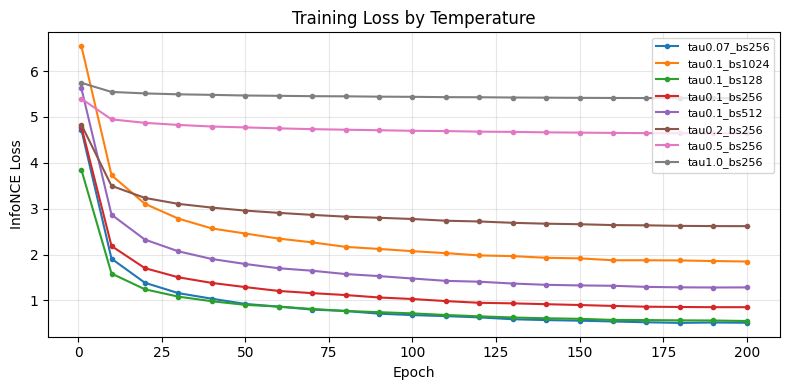

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

for run_name, records in runs.items():
    epochs = [r["epoch"] for r in records]
    losses = [r["loss"] for r in records]
    ax.plot(epochs, losses, marker="o", markersize=3, label=run_name)

ax.set_xlabel("Epoch")
ax.set_ylabel("InfoNCE Loss")
ax.set_title("Training Loss by Temperature")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/loss_curves.png", dpi=150)
plt.show()

## 3. Effective rank over training

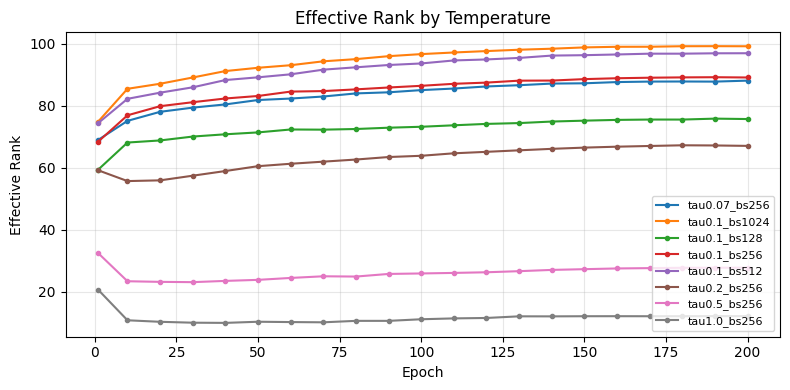

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for run_name, records in runs.items():
    epochs = [r["epoch"] for r in records]
    eranks = [r["effective_rank"] for r in records]
    ax.plot(epochs, eranks, marker="o", markersize=3, label=run_name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Effective Rank")
ax.set_title("Effective Rank by Temperature")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/effective_rank.png", dpi=150)
plt.show()

## 4. Uniformity and alignment

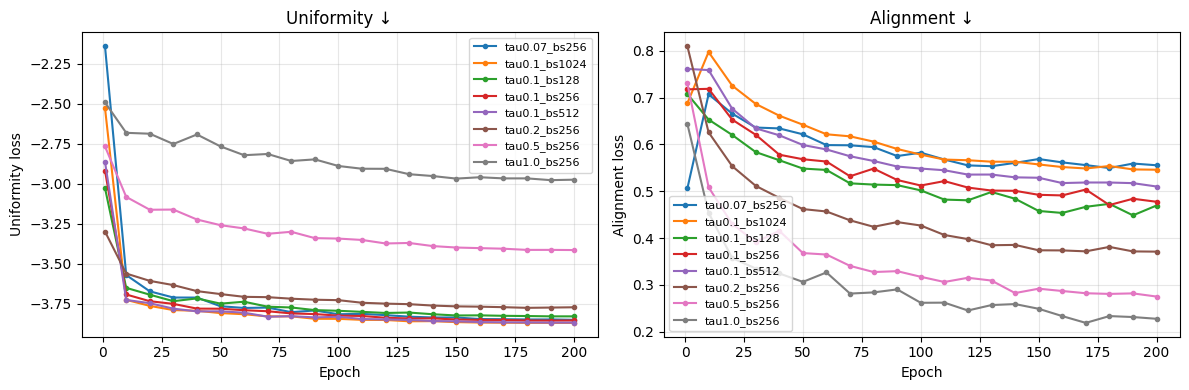

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for run_name, records in runs.items():
    epochs = [r["epoch"] for r in records]
    axes[0].plot(epochs, [r["uniformity"] for r in records], marker="o", markersize=3, label=run_name)
    axes[1].plot(epochs, [r["alignment"] for r in records], marker="o", markersize=3, label=run_name)

axes[0].set_title("Uniformity ↓")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Uniformity loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Alignment ↓")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Alignment loss")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/uniformity_alignment.png", dpi=150)
plt.show()

## 5. Uniformity vs Alignment (final epoch)

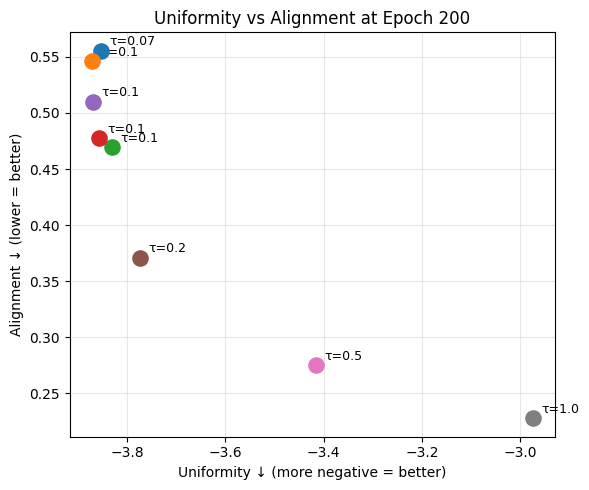

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

for run_name, records in runs.items():
    final = records[-1]
    tau = run_name.split("_")[0].replace("tau", "τ=")
    ax.scatter(final["uniformity"], final["alignment"], s=120, zorder=5)
    ax.annotate(tau, (final["uniformity"], final["alignment"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)

ax.set_xlabel("Uniformity ↓ (more negative = better)")
ax.set_ylabel("Alignment ↓ (lower = better)")
ax.set_title("Uniformity vs Alignment at Epoch 200")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/unif_align_scatter.png", dpi=150)
plt.show()

## 6. Summary table (final epoch)

In [8]:
print(f"{'Run':<20} {'Loss':>8} {'Uniformity':>12} {'Alignment':>12} {'Eff. Rank':>12}")
print("-" * 68)
for run_name, records in runs.items():
    final = records[-1]
    print(f"{run_name:<20} {final['loss']:>8.4f} {final['uniformity']:>12.4f} {final['alignment']:>12.4f} {final['effective_rank']:>12.2f}")

Run                      Loss   Uniformity    Alignment    Eff. Rank
--------------------------------------------------------------------
tau0.07_bs256          0.5125      -3.8517       0.5555        88.11
tau0.1_bs1024          1.8472      -3.8709       0.5460        99.19
tau0.1_bs128           0.5503      -3.8301       0.4696        75.73
tau0.1_bs256           0.8513      -3.8558       0.4776        89.13
tau0.1_bs512           1.2831      -3.8693       0.5102        96.94
tau0.2_bs256           2.6183      -3.7732       0.3711        67.08
tau0.5_bs256           4.6402      -3.4154       0.2752        27.83
tau1.0_bs256           5.4077      -2.9750       0.2277        12.22


## 7. Linear probe (downstream accuracy)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
from pathlib import Path

# modelo (misma arquitectura que train.py) 
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.projection_head = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, projection_dim)
        )
    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        return F.normalize(self.projection_head(h), dim=1)
    def encode(self, x):
        with torch.no_grad():
            return self.encoder(x).squeeze(-1).squeeze(-1)

# extrae embeddings del backbone 
def extract_features(model, loader, device):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            feats.append(model.encode(x.to(device)).cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

# dataloaders CIFAR-10 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]),
])
train_set = datasets.CIFAR10(root="../data", train=True,  download=True, transform=transform)
test_set  = datasets.CIFAR10(root="../data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=512, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=512, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# probe por run (checkpoint epoch_200) 
probe_results = {}
CHECKPOINTS_DIR = Path("../outputs/checkpoints")

for run_dir in sorted(CHECKPOINTS_DIR.iterdir()):
    ckpt_path = run_dir / "epoch_200.pt"
    if not ckpt_path.exists():
        continue

    model = SimCLRModel().to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    z_train, y_train = extract_features(model, train_loader, device)
    z_test,  y_test  = extract_features(model, test_loader,  device)

    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=0.1))
    clf.fit(z_train, y_train)
    acc = clf.score(z_test, y_test)

    probe_results[run_dir.name] = acc
    print(f"{run_dir.name}: test_acc = {acc:.4f}")

/home/nicolasaller/2Proyectos/EmbeddingCollapse/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


tau0.07_bs256: test_acc = 0.7131
tau0.1_bs1024: test_acc = 0.6933
tau0.1_bs128: test_acc = 0.7414
tau0.1_bs256: test_acc = 0.7330
tau0.1_bs512: test_acc = 0.7142
tau0.2_bs256: test_acc = 0.7533
tau0.5_bs256: test_acc = 0.7419
tau1.0_bs256: test_acc = 0.7137


## 8. Full results table

In [10]:
print(f"{'Run':<20} {'Loss':>8} {'Uniformity':>12} {'Alignment':>12} {'Eff. Rank':>10} {'Test Acc':>10}")
print("-" * 76)
for run_name, records in runs.items():
    final = records[-1]
    acc = probe_results.get(run_name, float("nan"))
    print(f"{run_name:<20} {final['loss']:>8.4f} {final['uniformity']:>12.4f} {final['alignment']:>12.4f} {final['effective_rank']:>10.2f} {acc:>10.4f}")

Run                      Loss   Uniformity    Alignment  Eff. Rank   Test Acc
----------------------------------------------------------------------------
tau0.07_bs256          0.5125      -3.8517       0.5555      88.11     0.7131
tau0.1_bs1024          1.8472      -3.8709       0.5460      99.19     0.6933
tau0.1_bs128           0.5503      -3.8301       0.4696      75.73     0.7414
tau0.1_bs256           0.8513      -3.8558       0.4776      89.13     0.7330
tau0.1_bs512           1.2831      -3.8693       0.5102      96.94     0.7142
tau0.2_bs256           2.6183      -3.7732       0.3711      67.08     0.7533
tau0.5_bs256           4.6402      -3.4154       0.2752      27.83     0.7419
tau1.0_bs256           5.4077      -2.9750       0.2277      12.22     0.7137


## 9. Singular value distribution (final epoch)

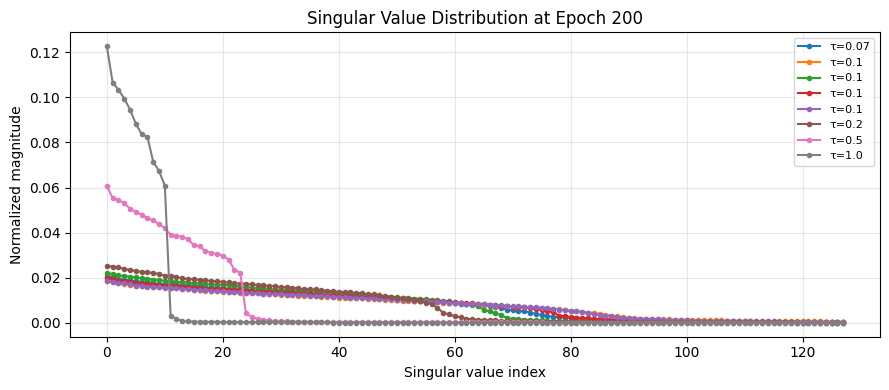

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from pathlib import Path

class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.projection_head = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, projection_dim)
        )
    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        return F.normalize(self.projection_head(h), dim=1)

device = torch.device("cpu")
CHECKPOINTS_DIR = Path("../outputs/checkpoints")

fig, ax = plt.subplots(figsize=(9, 4))

for run_dir in sorted(CHECKPOINTS_DIR.iterdir()):
    ckpt_path = run_dir / "epoch_200.pt"
    if not ckpt_path.exists():
        continue

    model = SimCLRModel().to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    # extrae embeddings de un batch
    with torch.no_grad():
        x, _ = next(iter(train_loader))
        z = model(x.to(device))

    sv = singular_value_distribution(z).cpu().numpy()
    tau = run_dir.name.split("_")[0].replace("tau", "τ=")
    ax.plot(sv, marker="o", markersize=3, label=tau)

ax.set_xlabel("Singular value index")
ax.set_ylabel("Normalized magnitude")
ax.set_title("Singular Value Distribution at Epoch 200")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/singular_values.png", dpi=150)
plt.show()

## 10. Batch size sweep — load logs

In [12]:
BS_RUNS = {k: v for k, v in runs.items() if k.startswith("tau0.1")}

# cargar los nuevos runs que no estaban antes
for run_dir in sorted(CHECKPOINTS_DIR.iterdir()):
    if run_dir.name not in runs:
        log_path = run_dir / "geometry_log.jsonl"
        if log_path.exists():
            records = [json.loads(line) for line in log_path.read_text().splitlines()]
            runs[run_dir.name] = records
            BS_RUNS[run_dir.name] = records
            print(f"Loaded {run_dir.name}: {len(records)} checkpoints")

print("\nBatch size runs:", list(BS_RUNS.keys()))


Batch size runs: ['tau0.1_bs1024', 'tau0.1_bs128', 'tau0.1_bs256', 'tau0.1_bs512']


## 11. Effective rank by batch size

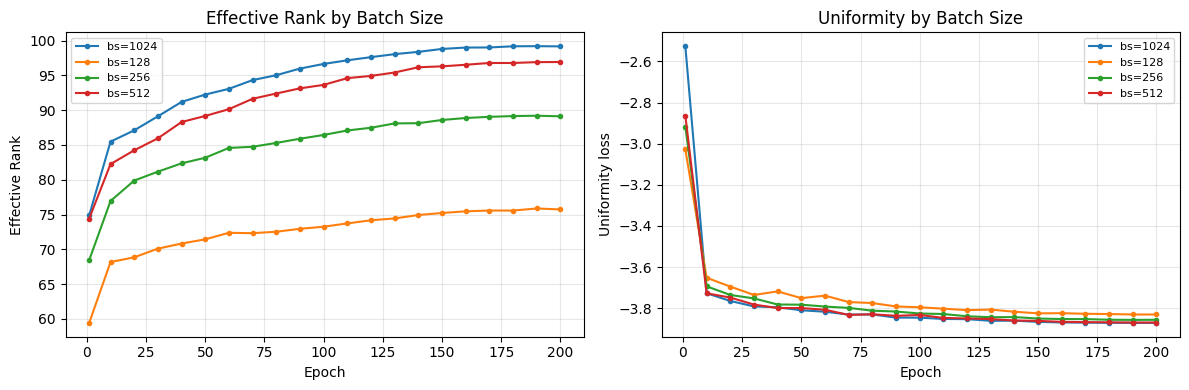

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for run_name, records in sorted(BS_RUNS.items()):
    epochs = [r["epoch"] for r in records]
    bs = run_name.split("_bs")[1]
    label = f"bs={bs}"
    axes[0].plot(epochs, [r["effective_rank"] for r in records], marker="o", markersize=3, label=label)
    axes[1].plot(epochs, [r["uniformity"] for r in records], marker="o", markersize=3, label=label)

axes[0].set_title("Effective Rank by Batch Size")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Effective Rank")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Uniformity by Batch Size")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Uniformity loss")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/batchsize_sweep.png", dpi=150)
plt.show()

## 12. Batch size summary table

In [14]:
print(f"{'Run':<22} {'Loss':>8} {'Uniformity':>12} {'Alignment':>12} {'Eff. Rank':>10}")
print("-" * 68)
for run_name, records in sorted(BS_RUNS.items()):
    final = records[-1]
    print(f"{run_name:<22} {final['loss']:>8.4f} {final['uniformity']:>12.4f} {final['alignment']:>12.4f} {final['effective_rank']:>10.2f}")

Run                        Loss   Uniformity    Alignment  Eff. Rank
--------------------------------------------------------------------
tau0.1_bs1024            1.8472      -3.8709       0.5460      99.19
tau0.1_bs128             0.5503      -3.8301       0.4696      75.73
tau0.1_bs256             0.8513      -3.8558       0.4776      89.13
tau0.1_bs512             1.2831      -3.8693       0.5102      96.94
